# 03: Quantum Teleportation — Circuit Implementation

We implement the section "Circuit Representation of the Protocol" and onward from the note `03_quantum_teleportation.md` in Qiskit and verify it by simulation.

**Contents:**
1. Bell pair generation circuit
2. Quantum teleportation circuit (full protocol) and verification

> **Notation note:** The notes and Qiskit differ in the starting index (1 vs 0) and the bit order in ket notation. See [01_qubit_ordering.ipynb](01_qubit_ordering.ipynb) for details. The physical results are not affected.

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
import numpy as np

**Import explanation:**

- `QuantumCircuit`: The basic class for building quantum circuits. Holds qubits and classical bits, to which gates and measurements are added.
- `QuantumRegister`: A named group of qubits. Used when distinguishing multiple registers.
- `ClassicalRegister`: A group of classical bits to store measurement results.
- `Statevector`: A class for computing and manipulating the state vector of a quantum circuit. Used for simulation.
- `numpy`: A numerical computation library. Used for amplitude computation and verification.

### Initial State

Initial values of each qubit in the circuit:

| Circuit qubit | Initial value | Role |
|---|---|---|
| $q_0$ | $\vert\psi\rangle = \alpha\vert 0\rangle + \beta\vert 1\rangle$ | State to be transferred |
| $q_1$ | $\vert 0\rangle$ | Alice's side of the Bell pair |
| $q_2$ | $\vert 0\rangle$ | Bob's side of the Bell pair |

By Qiskit's little-endian convention, the overall initial state in ket notation is:

$$
\vert q_2\, q_1\, q_0\rangle = \vert 0\rangle \otimes \vert 0\rangle \otimes \vert\psi\rangle = \vert 0, 0, \psi\rangle
$$

Note that $q_0$ (the state to be transferred) appears on the rightmost position. For example, if $\vert\psi\rangle = \vert 0\rangle$, the overall state is $\vert 000\rangle$.

## 1. Bell Pair Generation

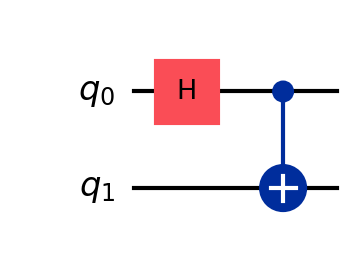

$$
\vert 00\rangle \xrightarrow{H \otimes I} \frac{\vert 0\rangle + \vert 1\rangle}{\sqrt{2}} \vert 0\rangle \xrightarrow{\text{CNOT}_{01}} \frac{\vert 00\rangle + \vert 11\rangle}{\sqrt{2}} = \vert\Phi^+\rangle
$$

First, we extract just the Bell pair generation and verify it. Here we construct it with 2 qubits, $q_0, q_1$.

(In the full teleportation circuit in Section 2, since $q_0$ is used for the state to be transferred, the Bell pair is generated on $q_1, q_2$.)

In [ ]:
# Bell pair generation circuit
bell = QuantumCircuit(2, name="Bell pair")
bell.h(0)
bell.cx(0, 1)

print(f"Bell pair generation circuit: {bell.num_qubits} qubits, gate count {bell.size()}")

**Code explanation:**

- `QuantumCircuit(2, name="Bell pair")`: Creates a 2-qubit circuit. The first argument `2` is the number of qubits. `name` is the circuit name.
- `bell.h(0)`: Applies the Hadamard gate $H$ to $q_0$.
- `bell.cx(0, 1)`: Applies $\text{CNOT}_{01}$. The first argument `0` is the control bit ($q_0$), and the second `1` is the target bit ($q_1$).

In [ ]:
# Check the state vector: |00⟩ + |11⟩ / √2
sv_bell = Statevector.from_instruction(bell)
print("Bell state |Φ+⟩:")
print(sv_bell.draw("text"))
print()
print("Amplitudes for each basis:")
for i, amp in enumerate(sv_bell):
    if abs(amp) > 1e-10:
        print(f"  |q_1 q_0⟩ = |{i:02b}⟩: {amp:.4f}")

**Code explanation:**

- `Statevector.from_instruction(bell)`: Computes the final state vector when the circuit `bell` is executed starting from $\vert 00\rangle$. A method to obtain the state directly via simulation, not on a real device.
- `sv.draw("text")`: Displays the state vector in text form.
- `enumerate(sv)`: Gets each amplitude of the state vector with an index. The index `i` corresponds to the computational basis $\vert i\rangle$ (Qiskit's little-endian convention).
- The `j` in the output is the imaginary unit (mathematician's/physicist's $i$). Python/NumPy uses `j` following the electrical engineering convention. For example, `0.7071+0.0000j` means $0.7071 + 0i$.

## 2. Quantum Teleportation Circuit (Full)

In Section 1 we extracted just the Bell pair generation for verification. Here we put the entire teleportation protocol, including Bell pair generation, into a single circuit.

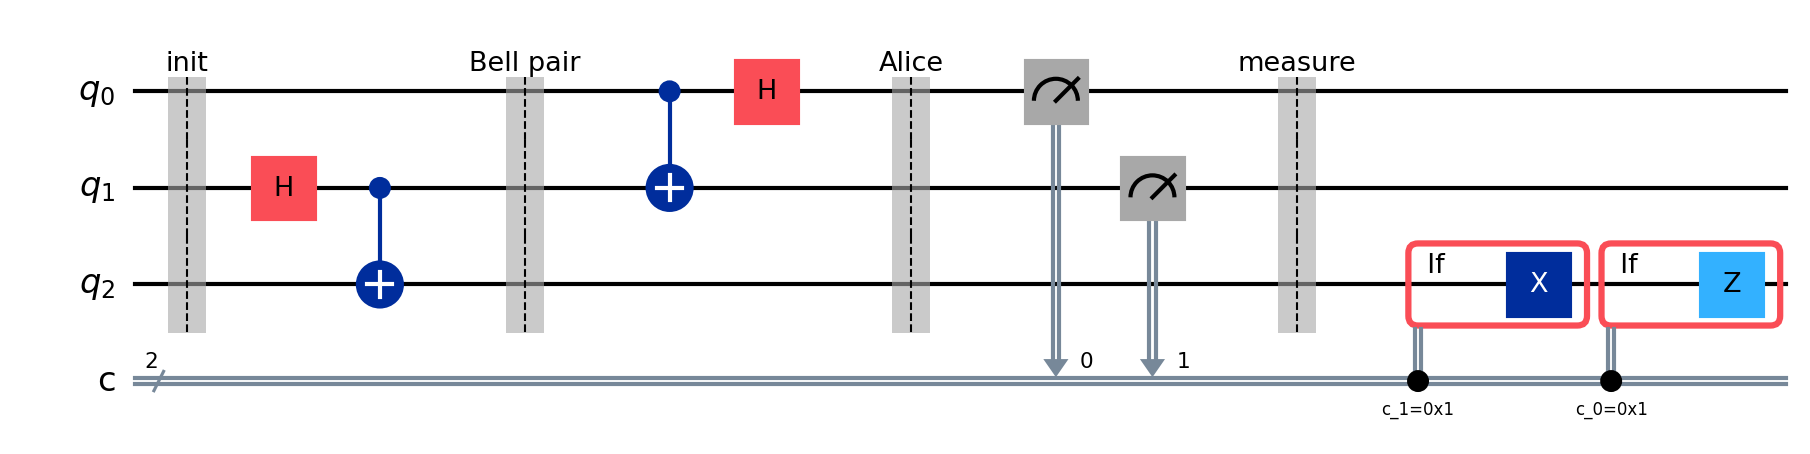

| Qiskit | Owner | Role |
|---|---|---|
| $q_0$ | Alice | State $\vert\psi\rangle$ to be transferred |
| $q_1$ | Alice | Alice's side of the Bell pair |
| $q_2$ | Bob | Bob's side of the Bell pair |

In [ ]:
def teleportation_circuit(init_gate=None):
    """Construct the quantum teleportation circuit.
    
    init_gate: initialization gate to apply to q[0] (defaults to leaving |0⟩)
    """
    q = QuantumRegister(3, "q")
    c = ClassicalRegister(2, "c")  # Alice's measurement results
    qc = QuantumCircuit(q, c)

    # --- Prepare the state to be transferred ---
    if init_gate is not None:
        qc.append(init_gate, [q[0]])
    qc.barrier(label="init")

    # --- Preparation phase: Bell pair generation (q[1], q[2]) ---
    qc.h(q[1])
    qc.cx(q[1], q[2])
    qc.barrier(label="Bell pair")

    # --- Alice's operations ---
    qc.cx(q[0], q[1])      # CNOT: q[0] (control), q[1] (target)
    qc.h(q[0])              # Hadamard: q[0]
    qc.barrier(label="Alice")

    # --- Measurement ---
    qc.measure(q[0], c[0])  # c[0] = measurement result of q[0]
    qc.measure(q[1], c[1])  # c[1] = measurement result of q[1]
    qc.barrier(label="measure")

    # --- Bob's correction ---
    with qc.if_test((c[1], 1)):  # Apply X if c[1]=1
        qc.x(q[2])
    with qc.if_test((c[0], 1)):  # Apply Z if c[0]=1
        qc.z(q[2])

    return qc

# Build the circuit (used for verification)
qc_teleport = teleportation_circuit()
print(f"Teleportation circuit: {qc_teleport.num_qubits} qubits, {qc_teleport.num_clbits} classical bits")

**Code explanation:**

- `QuantumRegister(3, "q")`: Creates a register of 3 qubits with the name `"q"`. Accessed as `q[0]`, `q[1]`, `q[2]`.
- `ClassicalRegister(2, "c")`: A register of 2 classical bits. Stores Alice's measurement results $c_0, c_1$.
- `QuantumCircuit(q, c)`: Creates a circuit by specifying the registers. Unlike `QuantumCircuit(3)`, the registers have names, making the circuit diagram easier to read.
- `qc.append(init_gate, [q[0]])`: Applies an arbitrary gate to the specified qubit.
- `qc.barrier(label="...")`: Inserts a separator on the circuit diagram. Visually divides logical phases of the circuit. Also serves as an optimization boundary.
- `qc.cx(q[0], q[1])`: $\text{CNOT}_{01}$ ($q_0$ control, $q_1$ target).
- `qc.measure(q[0], c[0])`: Measures $q_0$ and stores the result in classical bit `c[0]`.

**Bob's correction and correspondence with the notes:**

The conditions of `qc.if_test` correspond to the correction table (Step 4) in Note 03. In the notes, measurement results are written in the order $\vert q_1 q_2\rangle$, where $X$ is applied if $q_2$ (right side) is 1 and $Z$ is applied if $q_1$ (left side) is 1. In Qiskit:

| Notes (textbook) | Qiskit | Correction |
|---|---|---|
| $q_2 = 1$ (right side bit) | `c[1]` (measurement of $q_1$) = 1 | Apply $X$ to $q_2$ |
| $q_1 = 1$ (left side bit) | `c[0]` (measurement of $q_0$) = 1 | Apply $Z$ to $q_2$ |

### Reference: Verification of Teleportation with Various States

Since `teleportation_circuit()` contains `if_test` (conditional gates), the above circuit cannot be executed directly with `StatevectorSampler`. Therefore, although somewhat redundant, we rebuild a circuit without measurement or correction, extract Bob's state from the state vector, and verify that the correction works correctly.

In [ ]:
from qiskit.circuit.library import HGate, XGate

def verify_teleportation(init_gate, label):
    """Get the state vector with a measurement-free circuit and verify that the original state is recovered after correction."""
    # Circuit without measurement or correction
    qc = QuantumCircuit(3)
    if init_gate is not None:
        qc.append(init_gate, [0])
    qc.h(1)
    qc.cx(1, 2)
    qc.cx(0, 1)
    qc.h(0)
    
    sv = Statevector.from_instruction(qc)
    
    # Get the original state (apply init_gate to a 1-qubit circuit)
    qc_ref = QuantumCircuit(1)
    if init_gate is not None:
        qc_ref.append(init_gate, [0])
    psi = np.array(Statevector.from_instruction(qc_ref))
    
    # Correction gates
    I_gate = np.eye(2)
    X_gate = np.array([[0, 1], [1, 0]])
    Z_gate = np.array([[1, 0], [0, -1]])
    corrections = {"I": I_gate, "X": X_gate, "Z": Z_gate, "ZX": Z_gate @ X_gate}
    
    # 4 patterns of Alice's measurement results (q0, q1)
    patterns = [("00", 0, 0, "I"), ("01", 0, 1, "X"), ("10", 1, 0, "Z"), ("11", 1, 1, "ZX")]
    
    print(f"State to transfer: {label}")
    all_ok = True
    for bits, m0, m1, corr_name in patterns:
        # Extract Bob's state (index = q0 + q1*2 + q2*4)
        idx0 = m0 + m1 * 2 + 0 * 4
        idx1 = m0 + m1 * 2 + 1 * 4
        bob = np.array([sv[idx0], sv[idx1]])
        bob = bob / np.linalg.norm(bob)
        
        # Apply the correction
        corrected = corrections[corr_name] @ bob
        
        # Compare modulo global phase
        if abs(corrected[0]) > 1e-10:
            corrected = corrected * (psi[0] / corrected[0])
        elif abs(corrected[1]) > 1e-10:
            corrected = corrected * (psi[1] / corrected[1])
        
        ok = np.allclose(corrected, psi, atol=1e-6)
        all_ok = all_ok and ok
        print(f"  |{m1}{m0}⟩ → correction {corr_name:2s} → {'✓' if ok else '✗'}")
    
    print(f"  Result: {'success' if all_ok else 'failure'}")
    print()
    return all_ok

# Verify with various initial states
verify_teleportation(None,    "|0⟩")
verify_teleportation(XGate(), "|1⟩")
verify_teleportation(HGate(), "|+⟩")

**Code explanation:**

- `qc.append(init_gate, [0])`: Apply `init_gate` (e.g., `HGate()`) to $q_0$ to prepare the state to be transferred.
- `Statevector.from_instruction(qc)`: Get the state vector from a measurement-free circuit. Since adding measurement collapses the state, the verification uses a measurement-free circuit.

**Structure of the state vector `sv`:**

With 3 qubits, there are $2^3 = 8$ computational basis states. `sv` is an array of length 8 holding all these amplitudes. The index follows Qiskit's little-endian convention: `index = q0 + q1*2 + q2*4`.

| index | $\vert q_2\, q_1\, q_0\rangle$ | `sv[index]` |
|---|---|---|
| 0 | $\vert 000\rangle$ | the amplitude |
| 1 | $\vert 001\rangle$ | the amplitude |
| 2 | $\vert 010\rangle$ | the amplitude |
| 3 | $\vert 011\rangle$ | the amplitude |
| 4 | $\vert 100\rangle$ | the amplitude |
| 5 | $\vert 101\rangle$ | the amplitude |
| 6 | $\vert 110\rangle$ | the amplitude |
| 7 | $\vert 111\rangle$ | the amplitude |

**The mechanism for extracting Bob's state with `idx0`, `idx1`:**

`sv` is the state vector of all 3 qubits ($q_0, q_1, q_2$); each `sv[i]` alone is not the state of $q_2$.

However, **assuming** that Alice measures $q_0$ and $q_1$ and obtains results $q_0 = m_0$, $q_1 = m_1$, the values of $q_0$ and $q_1$ are fixed, leaving only 2 of the 8 amplitudes. The remaining freedom is whether Bob's $q_2$ is 0 or 1.

For example, if Alice's measurement result is $q_0 = 1$, $q_1 = 0$ ($\vert 01\rangle$):
- `idx0 = 1 + 0*2 + 0*4 = 1` → $\vert q_2 q_1 q_0\rangle = \vert 001\rangle$ ($q_2 = 0$)
- `idx1 = 1 + 0*2 + 1*4 = 5` → $\vert q_2 q_1 q_0\rangle = \vert 101\rangle$ ($q_2 = 1$)

Extracting `sv[1]` and `sv[5]` as `[sv[1], sv[5]]` gives "the state vector of Bob's $q_2$ when Alice obtains this measurement result" $a\vert 0\rangle + b\vert 1\rangle$. After normalization (each measurement result has probability $1/4$), the correction gate is applied and verified to match the original $\vert\psi\rangle$.

**Comparison with `np.allclose`:**

`np.allclose(a, b, atol=1e-6)` compares each element of two arrays and returns `True` if all are within the tolerance. Due to floating-point rounding error, `==` is not used; `allclose` is used to determine "approximate equality."

**Global phase correction:**

In quantum mechanics, $|\psi\rangle$ and $e^{i\theta}|\psi\rangle$ are physically the same state. The corrected Bob's state `corrected` may differ from the original `psi` only by a global phase $e^{i\theta}$. Therefore:

1. Compute the phase factor $e^{i\theta}$ in reverse with `phase = psi[0] / corrected[0]`
2. Align the phase with `corrected * phase`
3. Determine whether it matches `psi` with `np.allclose`